# mmraz-probe-variations-question-options-answer

Goal: run a focused GPT-2 probe-format experiment under a question-first prompt template, keeping only the comparison between:

- answer **last-token** residual stream features, and
- **mean answer-token** residual stream features.

This notebook follows the general structure of `mmraz-probe-variations-red-team-20260322-090107.ipynb`, but only does the prompt-format experiment below.

## Prompt format

```text
{question}
Options:
  {option_a_text_stripped}
  {option_b_text_stripped}
  Answer:
```

Probe training remains teacher-forced: each pair yields two examples with the same prompt and different stripped answer continuations, one immediate/short-term and one long-term.

The notebook fits four linear probe families under both feature-extraction methods:

- LogisticRegression (LR)
- whitened LogisticRegression (WLR)
- mean-mass (MM)
- whitened mean-mass (WMM)


In [ ]:
import os
from pathlib import Path
import hashlib
import json
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp/mplconfig")))
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)


In [ ]:
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "pyproject.toml").exists() and (p / "data").exists():
            return p
        p = p.parent
    raise RuntimeError("Could not locate repo root from current working directory.")


def pick_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError("None of these paths exist: " + str(paths))


def load_pairs(path: Path):
    data = json.loads(path.read_text())
    if isinstance(data, dict) and "pairs" in data:
        return data.get("metadata", {}), data["pairs"]
    return {}, data


def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


ROOT = find_repo_root(Path.cwd())
RESULTS_DIR = ROOT / "results"

explicit_expanded_path = pick_first_existing(
    [
        ROOT / "data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json",
        ROOT / "data/raw/temporal_scope/temporal_scope_explicit_expanded_500.json",
        ROOT / "data/raw/temporal_scope_explicit_expanded_500.json",
    ]
)
implicit_expanded_path = pick_first_existing(
    [
        ROOT / "data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json",
        ROOT / "data/raw/temporal_scope/temporal_scope_implicit_expanded_300.json",
        ROOT / "data/raw/temporal_scope_implicit_expanded_300.json",
    ]
)

exp_meta, explicit_pairs = load_pairs(explicit_expanded_path)
imp_meta, implicit_pairs = load_pairs(implicit_expanded_path)

print("Repo root:", ROOT)
print("Expanded explicit dataset:", explicit_expanded_path)
print("Expanded implicit dataset:", implicit_expanded_path)
print("Expanded explicit metadata:", exp_meta)
print("Expanded implicit metadata:", imp_meta)
print("Expanded explicit pairs:", len(explicit_pairs))
print("Expanded implicit pairs:", len(implicit_pairs))

hash_df = pd.DataFrame(
    [
        {
            "dataset": "explicit_expanded_500",
            "path": str(explicit_expanded_path.relative_to(ROOT)),
            "sha256": sha256(explicit_expanded_path),
        },
        {
            "dataset": "implicit_expanded_300",
            "path": str(implicit_expanded_path.relative_to(ROOT)),
            "sha256": sha256(implicit_expanded_path),
        },
    ]
)
display(hash_df)
display(pd.DataFrame(explicit_pairs).head(3))


In [ ]:
def extract_option_letter(option_text):
    match = re.search(r"\(([ABab])\)", option_text or "")
    return match.group(1).upper() if match else None


def strip_option_label(option_text):
    return re.sub(r"^\s*\([ABab]\)\s*", "", option_text or "").strip()


def get_pair_option_payload(pair):
    immediate_letter = extract_option_letter(pair["immediate"])
    long_term_letter = extract_option_letter(pair["long_term"])

    if immediate_letter and long_term_letter and immediate_letter != long_term_letter:
        option_a_text = pair["immediate"] if immediate_letter == "A" else pair["long_term"]
        option_b_text = pair["immediate"] if immediate_letter == "B" else pair["long_term"]
    else:
        option_a_text = pair["immediate"]
        option_b_text = pair["long_term"]

    return {
        "option_a_text": option_a_text,
        "option_b_text": option_b_text,
        "immediate_text": pair["immediate"],
        "long_term_text": pair["long_term"],
    }


def build_probe_prompt(question_text, option_a_text, option_b_text):
    question_text = (question_text or "").strip()
    option_a_text = strip_option_label(option_a_text)
    option_b_text = strip_option_label(option_b_text)
    return (
        f"{question_text}\n"
        "Options:\n"
        f"  {option_a_text}\n"
        f"  {option_b_text}\n"
        "  Answer:\n"
    )


def build_teacher_forced_examples_from_pairs(pairs):
    examples = []
    labels = []

    for pair in pairs:
        option_payload = get_pair_option_payload(pair)
        prompt = build_probe_prompt(
            pair["question"],
            option_payload["option_a_text"],
            option_payload["option_b_text"],
        )

        examples.append(
            {
                "prompt": prompt,
                "continuation": strip_option_label(option_payload["immediate_text"]),
                "label": 0,
            }
        )
        labels.append(0)

        examples.append(
            {
                "prompt": prompt,
                "continuation": strip_option_label(option_payload["long_term_text"]),
                "label": 1,
            }
        )
        labels.append(1)

    return examples, np.array(labels, dtype=np.int64)


explicit_examples, y_exp = build_teacher_forced_examples_from_pairs(explicit_pairs)
implicit_examples, y_imp = build_teacher_forced_examples_from_pairs(implicit_pairs)

print("Expanded explicit samples:", len(y_exp), "| class balance:", np.bincount(y_exp))
print("Expanded implicit samples:", len(y_imp), "| class balance:", np.bincount(y_imp))
print("Prompt example:")
print(repr(explicit_examples[0]["prompt"]))
print("Continuation example:")
print(repr(explicit_examples[0]["continuation"]))


In [ ]:
MODEL_NAME = "gpt2"
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, local_files_only=True).to(device)
model.eval()
n_layers = model.config.n_layer
print("Loaded", MODEL_NAME, "| n_layers =", n_layers, "| d_model =", model.config.n_embd)


In [ ]:
@torch.no_grad()
def extract_answer_token_activations(examples, pooling="mean", batch_size=16):
    if pooling not in {"mean", "last"}:
        raise ValueError(f"Unexpected pooling mode: {pooling!r}")

    by_layer = {layer: [] for layer in range(n_layers)}
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

    for start in range(0, len(examples), batch_size):
        batch_examples = examples[start : start + batch_size]
        prompt_ids_batch = []
        continuation_ids_batch = []
        seq_lengths = []
        answer_spans = []

        for example in batch_examples:
            prompt_ids = tokenizer(
                example["prompt"],
                add_special_tokens=False,
                return_tensors="pt",
            )["input_ids"][0]
            continuation_ids = tokenizer(
                example["continuation"],
                add_special_tokens=False,
                return_tensors="pt",
            )["input_ids"][0]
            if continuation_ids.numel() == 0:
                raise ValueError(f"Empty continuation for probe example: {example!r}")

            prompt_ids_batch.append(prompt_ids)
            continuation_ids_batch.append(continuation_ids)
            seq_lengths.append(int(prompt_ids.shape[0] + continuation_ids.shape[0]))

        max_seq_len = max(seq_lengths)
        input_ids = torch.full((len(batch_examples), max_seq_len), pad_id, dtype=torch.long)
        attention_mask = torch.zeros((len(batch_examples), max_seq_len), dtype=torch.long)

        for row_idx, (prompt_ids, continuation_ids) in enumerate(zip(prompt_ids_batch, continuation_ids_batch)):
            seq = torch.cat([prompt_ids, continuation_ids], dim=0)
            seq_len = int(seq.shape[0])
            answer_start = int(prompt_ids.shape[0])
            answer_end = seq_len

            input_ids[row_idx, :seq_len] = seq
            attention_mask[row_idx, :seq_len] = 1
            answer_spans.append((answer_start, answer_end))

        batch = {
            "input_ids": input_ids.to(device),
            "attention_mask": attention_mask.to(device),
        }
        out = model(**batch, output_hidden_states=True)

        for layer in range(n_layers):
            hs = out.hidden_states[layer + 1]
            pooled_rows = []
            for row_idx, (answer_start, answer_end) in enumerate(answer_spans):
                if pooling == "mean":
                    pooled = hs[row_idx, answer_start:answer_end, :].mean(dim=0)
                else:
                    pooled = hs[row_idx, answer_end - 1, :]
                pooled_rows.append(pooled.detach().cpu().numpy())
            by_layer[layer].append(np.stack(pooled_rows, axis=0))

    for layer in by_layer:
        by_layer[layer] = np.concatenate(by_layer[layer], axis=0)

    return by_layer


print("Extracting mean answer-token residual features...")
X_exp_mean = extract_answer_token_activations(explicit_examples, pooling="mean", batch_size=16)
X_imp_mean = extract_answer_token_activations(implicit_examples, pooling="mean", batch_size=16)

print("Extracting last answer-token residual features...")
X_exp_last = extract_answer_token_activations(explicit_examples, pooling="last", batch_size=16)
X_imp_last = extract_answer_token_activations(implicit_examples, pooling="last", batch_size=16)

print("Mean pooling explicit layer 0:", X_exp_mean[0].shape)
print("Mean pooling implicit layer 0:", X_imp_mean[0].shape)
print("Last-token explicit layer 0:", X_exp_last[0].shape)
print("Last-token implicit layer 0:", X_imp_last[0].shape)


In [ ]:
def train_mm_probe(X_train, y_train):
    mu0 = X_train[y_train == 0].mean(axis=0)
    mu1 = X_train[y_train == 1].mean(axis=0)
    return mu1 - mu0


def mm_predict(X, direction):
    scores = X @ direction
    return (scores > 0).astype(np.int64), scores


def fit_whitener(X_train, reg=1e-2):
    mean_train = X_train.mean(axis=0)
    Xc = X_train - mean_train

    cov = np.cov(Xc, rowvar=False, bias=False)
    avg_var = float(np.trace(cov) / cov.shape[0]) if cov.shape[0] > 0 else 1.0
    cov_reg = cov + (reg * avg_var) * np.eye(cov.shape[0], dtype=cov.dtype)

    precision = np.linalg.pinv(cov_reg)

    eigvals, eigvecs = np.linalg.eigh(cov_reg)
    eigvals = np.clip(eigvals, 1e-12, None)
    inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    try:
        cond = float(np.linalg.cond(cov_reg))
    except Exception:
        cond = float("nan")

    return {
        "mean_train": mean_train,
        "cov_reg": cov_reg,
        "precision": precision,
        "inv_sqrt": inv_sqrt,
        "reg": reg,
        "cov_reg_condition_number": cond,
    }


def apply_whitener(X, whitener):
    Xc = X - whitener["mean_train"]
    return Xc @ whitener["inv_sqrt"]


def train_whitened_mm_probe(X_train, y_train, reg=1e-2):
    mu0 = X_train[y_train == 0].mean(axis=0)
    mu1 = X_train[y_train == 1].mean(axis=0)
    mm_direction = mu1 - mu0

    whitener = fit_whitener(X_train, reg=reg)
    effective_direction = whitener["precision"] @ mm_direction

    return {
        "mean_train": whitener["mean_train"],
        "effective_direction": effective_direction,
        "reg": whitener["reg"],
        "cov_reg_condition_number": whitener["cov_reg_condition_number"],
    }


def whitened_mm_predict(X, model):
    Xc = X - model["mean_train"]
    scores = Xc @ model["effective_direction"]
    return (scores > 0).astype(np.int64), scores


def evaluate_probe_family(X_exp, X_imp, y_exp, y_imp, feature_name):
    indices = np.arange(len(y_exp))
    train_idx, test_idx = train_test_split(
        indices,
        test_size=0.2,
        random_state=42,
        stratify=y_exp,
    )

    rows = []
    for layer in range(n_layers):
        X_train = X_exp[layer][train_idx]
        y_train = y_exp[train_idx]
        X_test = X_exp[layer][test_idx]
        y_test = y_exp[test_idx]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            lr_probe = LogisticRegression(max_iter=1000, random_state=42)
            lr_probe.fit(X_train, y_train)

        whitener = fit_whitener(X_train, reg=1e-2)
        X_train_w = apply_whitener(X_train, whitener)
        X_test_w = apply_whitener(X_test, whitener)
        X_imp_w = apply_whitener(X_imp[layer], whitener)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            wlr_probe = LogisticRegression(max_iter=1000, random_state=42)
            wlr_probe.fit(X_train_w, y_train)

        mm_direction = train_mm_probe(X_train, y_train)
        mm_pred_test, _ = mm_predict(X_test, mm_direction)
        mm_pred_imp, _ = mm_predict(X_imp[layer], mm_direction)

        wmm_model = train_whitened_mm_probe(X_train, y_train, reg=1e-2)
        wmm_pred_test, _ = whitened_mm_predict(X_test, wmm_model)
        wmm_pred_imp, _ = whitened_mm_predict(X_imp[layer], wmm_model)

        rows.append(
            {
                "feature_name": feature_name,
                "layer": layer,
                "lr_explicit_test_acc": float((lr_probe.predict(X_test) == y_test).mean()),
                "lr_implicit_acc": float((lr_probe.predict(X_imp[layer]) == y_imp).mean()),
                "wlr_explicit_test_acc": float((wlr_probe.predict(X_test_w) == y_test).mean()),
                "wlr_implicit_acc": float((wlr_probe.predict(X_imp_w) == y_imp).mean()),
                "mm_explicit_test_acc": float((mm_pred_test == y_test).mean()),
                "mm_implicit_acc": float((mm_pred_imp == y_imp).mean()),
                "wmm_explicit_test_acc": float((wmm_pred_test == y_test).mean()),
                "wmm_implicit_acc": float((wmm_pred_imp == y_imp).mean()),
                "whitener_cov_reg_condition_number": float(whitener["cov_reg_condition_number"]),
            }
        )

    return pd.DataFrame(rows).sort_values("layer").reset_index(drop=True)


mean_metrics_df = evaluate_probe_family(X_exp_mean, X_imp_mean, y_exp, y_imp, "mean_answer_tokens")
last_metrics_df = evaluate_probe_family(X_exp_last, X_imp_last, y_exp, y_imp, "last_answer_token")

all_metrics_df = pd.concat([last_metrics_df, mean_metrics_df], ignore_index=True)
display(all_metrics_df)

summary_rows = []
for feature_name, feature_df in all_metrics_df.groupby("feature_name"):
    summary_rows.append(
        {
            "feature_name": feature_name,
            "best_lr_explicit_layer": int(feature_df.loc[feature_df["lr_explicit_test_acc"].idxmax(), "layer"]),
            "best_lr_explicit_acc": float(feature_df["lr_explicit_test_acc"].max()),
            "best_lr_implicit_layer": int(feature_df.loc[feature_df["lr_implicit_acc"].idxmax(), "layer"]),
            "best_lr_implicit_acc": float(feature_df["lr_implicit_acc"].max()),
            "best_wlr_explicit_layer": int(feature_df.loc[feature_df["wlr_explicit_test_acc"].idxmax(), "layer"]),
            "best_wlr_explicit_acc": float(feature_df["wlr_explicit_test_acc"].max()),
            "best_wlr_implicit_layer": int(feature_df.loc[feature_df["wlr_implicit_acc"].idxmax(), "layer"]),
            "best_wlr_implicit_acc": float(feature_df["wlr_implicit_acc"].max()),
            "best_mm_explicit_layer": int(feature_df.loc[feature_df["mm_explicit_test_acc"].idxmax(), "layer"]),
            "best_mm_explicit_acc": float(feature_df["mm_explicit_test_acc"].max()),
            "best_mm_implicit_layer": int(feature_df.loc[feature_df["mm_implicit_acc"].idxmax(), "layer"]),
            "best_mm_implicit_acc": float(feature_df["mm_implicit_acc"].max()),
            "best_wmm_explicit_layer": int(feature_df.loc[feature_df["wmm_explicit_test_acc"].idxmax(), "layer"]),
            "best_wmm_explicit_acc": float(feature_df["wmm_explicit_test_acc"].max()),
            "best_wmm_implicit_layer": int(feature_df.loc[feature_df["wmm_implicit_acc"].idxmax(), "layer"]),
            "best_wmm_implicit_acc": float(feature_df["wmm_implicit_acc"].max()),
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


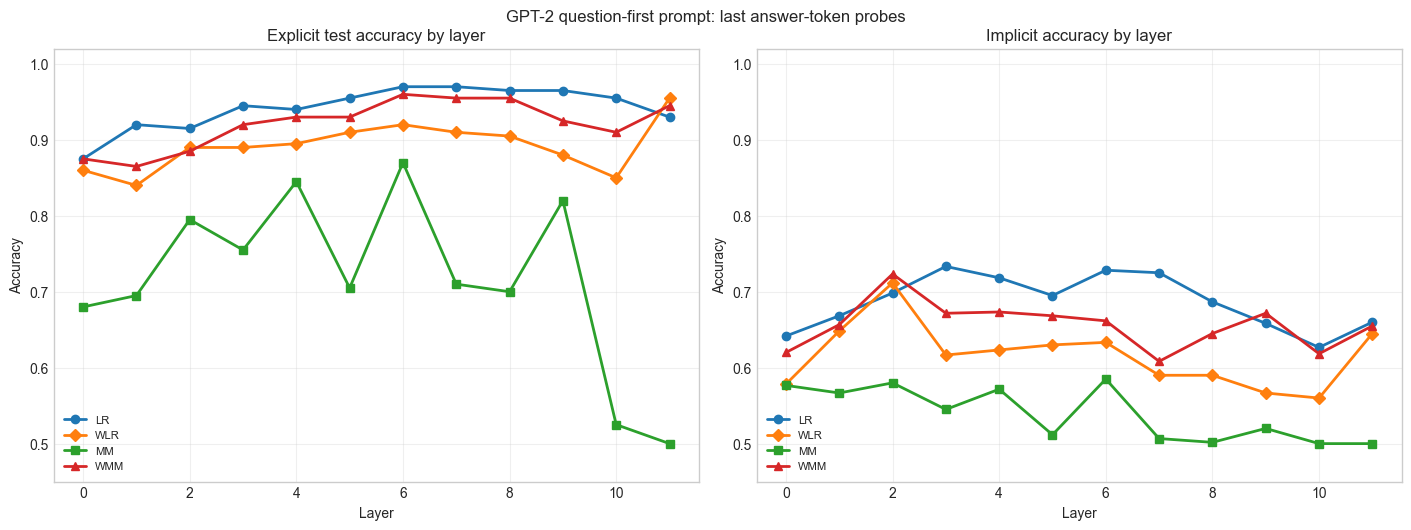

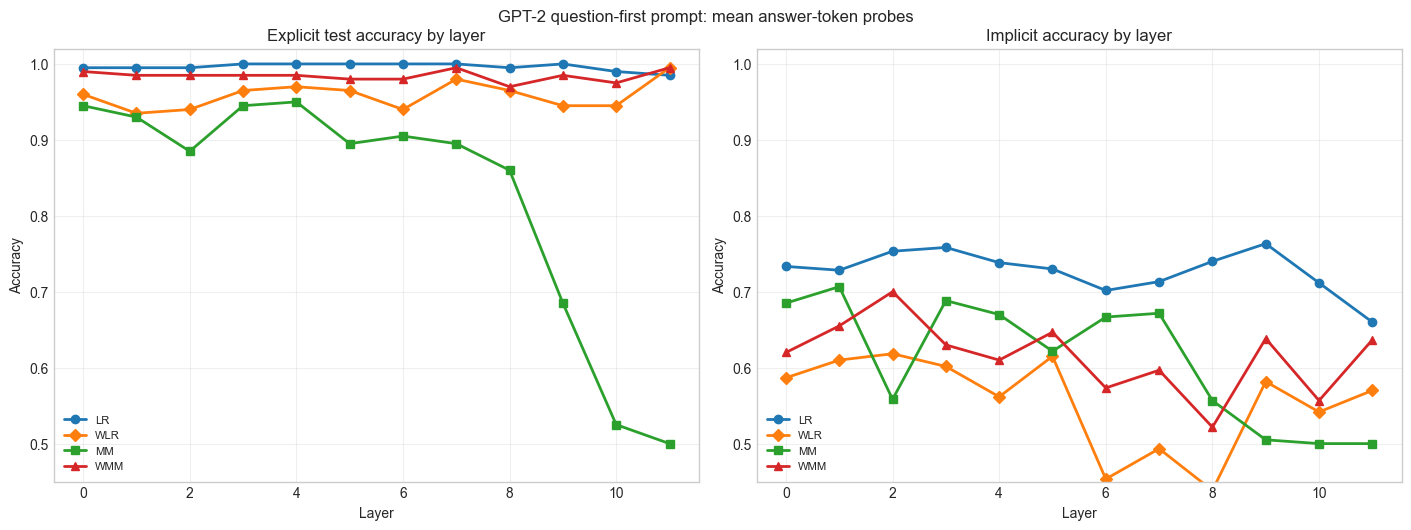

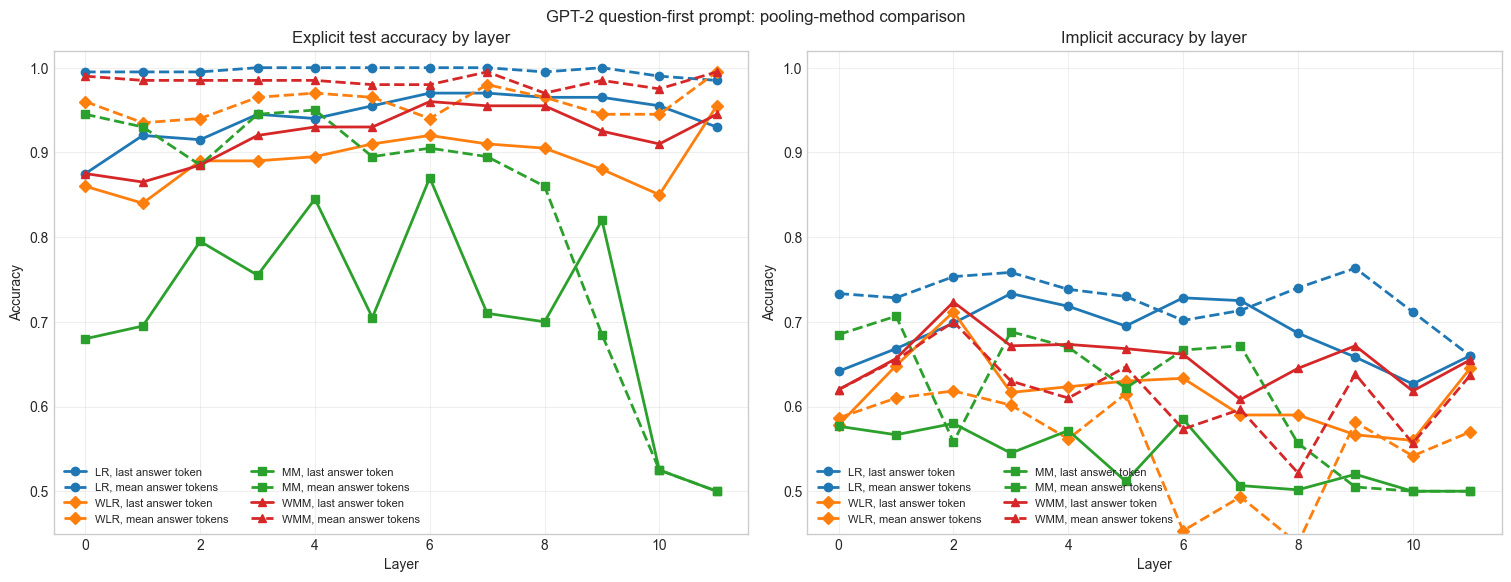

In [17]:
STYLE_LAST_ONLY = {
    "lr_explicit_test_acc": {"label": "LR", "color": "C0", "marker": "o"},
    "wlr_explicit_test_acc": {"label": "WLR", "color": "C1", "marker": "D"},
    "mm_explicit_test_acc": {"label": "MM", "color": "C2", "marker": "s"},
    "wmm_explicit_test_acc": {"label": "WMM", "color": "C3", "marker": "^"},
}

STYLE_MEAN_ONLY = {
    "lr_explicit_test_acc": {"label": "LR", "color": "C0", "marker": "o"},
    "wlr_explicit_test_acc": {"label": "WLR", "color": "C1", "marker": "D"},
    "mm_explicit_test_acc": {"label": "MM", "color": "C2", "marker": "s"},
    "wmm_explicit_test_acc": {"label": "WMM", "color": "C3", "marker": "^"},
}

STYLE_COMPARISON = {
    "lr": {
        "last": {"color": "C0", "marker": "o", "linestyle": "-", "label": "LR, last answer token"},
        "mean": {"color": "C0", "marker": "o", "linestyle": "--", "label": "LR, mean answer tokens"},
    },
    "wlr": {
        "last": {"color": "C1", "marker": "D", "linestyle": "-", "label": "WLR, last answer token"},
        "mean": {"color": "C1", "marker": "D", "linestyle": "--", "label": "WLR, mean answer tokens"},
    },
    "mm": {
        "last": {"color": "C2", "marker": "s", "linestyle": "-", "label": "MM, last answer token"},
        "mean": {"color": "C2", "marker": "s", "linestyle": "--", "label": "MM, mean answer tokens"},
    },
    "wmm": {
        "last": {"color": "C3", "marker": "^", "linestyle": "-", "label": "WMM, last answer token"},
        "mean": {"color": "C3", "marker": "^", "linestyle": "--", "label": "WMM, mean answer tokens"},
    },
}


def draw_pooling_only_figure(df, pooling_label, title_prefix, style_map):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, metric, title in [
        (axes[0], "explicit_test_acc", "Explicit test accuracy by layer"),
        (axes[1], "implicit_acc", "Implicit accuracy by layer"),
    ]:
        for family in ["lr", "wlr", "mm", "wmm"]:
            col = f"{family}_{metric}"
            style = style_map[f"{family}_explicit_test_acc"]
            ax.plot(
                df["layer"],
                df[col],
                marker=style["marker"],
                linewidth=2,
                color=style["color"],
                label=style["label"],
            )
        ax.set_title(title)
        ax.set_xlabel("Layer")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0.45, 1.02)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="lower left", fontsize=8)
    fig.suptitle(title_prefix, y=1.03)
    return fig


def draw_comparison_figure(last_df, mean_df):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    for ax, metric, title in [
        (axes[0], "explicit_test_acc", "Explicit test accuracy by layer"),
        (axes[1], "implicit_acc", "Implicit accuracy by layer"),
    ]:
        for family in ["lr", "wlr", "mm", "wmm"]:
            last_style = STYLE_COMPARISON[family]["last"]
            mean_style = STYLE_COMPARISON[family]["mean"]
            ax.plot(
                last_df["layer"],
                last_df[f"{family}_{metric}"],
                linewidth=2,
                marker=last_style["marker"],
                linestyle=last_style["linestyle"],
                color=last_style["color"],
                label=last_style["label"],
            )
            ax.plot(
                mean_df["layer"],
                mean_df[f"{family}_{metric}"],
                linewidth=2,
                marker=mean_style["marker"],
                linestyle=mean_style["linestyle"],
                color=mean_style["color"],
                label=mean_style["label"],
            )
        ax.set_title(title)
        ax.set_xlabel("Layer")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0.45, 1.02)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="lower left", fontsize=8, ncol=2)
    fig.suptitle("GPT-2 question-first prompt: pooling-method comparison", y=1.03)
    return fig


last_only_fig = draw_pooling_only_figure(
    last_metrics_df,
    "last_answer_token",
    "GPT-2 question-first prompt: last answer-token probes",
    STYLE_LAST_ONLY,
)
plt.show()

mean_only_fig = draw_pooling_only_figure(
    mean_metrics_df,
    "mean_answer_tokens",
    "GPT-2 question-first prompt: mean answer-token probes",
    STYLE_MEAN_ONLY,
)
plt.show()

comparison_fig = draw_comparison_figure(last_metrics_df, mean_metrics_df)
plt.show()


In [18]:
metrics_path = RESULTS_DIR / "gpt2_question_options_answer_probe_pooling_metrics.csv"
last_only_figure_path = RESULTS_DIR / "gpt2_question_options_answer_probe_last_token_only.png"
mean_only_figure_path = RESULTS_DIR / "gpt2_question_options_answer_probe_mean_token_only.png"
comparison_figure_path = RESULTS_DIR / "gpt2_question_options_answer_probe_pooling_comparison.png"

all_metrics_df.to_csv(metrics_path, index=False)
last_only_fig.savefig(last_only_figure_path, dpi=200, bbox_inches="tight")
mean_only_fig.savefig(mean_only_figure_path, dpi=200, bbox_inches="tight")
comparison_fig.savefig(comparison_figure_path, dpi=200, bbox_inches="tight")

print("Saved metrics to:", metrics_path)
print("Saved last-token figure to:", last_only_figure_path)
print("Saved mean-token figure to:", mean_only_figure_path)
print("Saved comparison figure to:", comparison_figure_path)


Saved metrics to: /Users/michalmraz/code/spar-ai/temporal-awareness/results/gpt2_question_options_answer_probe_pooling_metrics.csv
Saved last-token figure to: /Users/michalmraz/code/spar-ai/temporal-awareness/results/gpt2_question_options_answer_probe_last_token_only.png
Saved mean-token figure to: /Users/michalmraz/code/spar-ai/temporal-awareness/results/gpt2_question_options_answer_probe_mean_token_only.png
Saved comparison figure to: /Users/michalmraz/code/spar-ai/temporal-awareness/results/gpt2_question_options_answer_probe_pooling_comparison.png


The notebook above isolates one change only: adding the question back into the prompt while comparing answer-span feature extraction choices. The resulting metrics and plot are saved under `results/` for reuse outside the notebook.